In [1]:
# Importar las librerias de uso común
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


### Abrir archivo y analizar su información general
- **Importar** archivo
- Aplicar función **.info()**
- Analizar los **valores nulos**

In [2]:
#Importar archivo
games = pd.read_csv('../games.csv')

In [3]:
print(games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [4]:
#Valores nulos por columna
print(games.isna().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


In [5]:
print(games)

                                Name Platform  Year_of_Release         Genre  \
0                         Wii Sports      Wii           2006.0        Sports   
1                  Super Mario Bros.      NES           1985.0      Platform   
2                     Mario Kart Wii      Wii           2008.0        Racing   
3                  Wii Sports Resort      Wii           2009.0        Sports   
4           Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3           2016.0        Action   
16711               LMA Manager 2007     X360           2006.0        Sports   
16712        Haitaka no Psychedelica      PSV           2016.0     Adventure   
16713               Spirits & Spells      GBA           2003.0      Platform   
16714            Winning Post 8 2016      PSV           2016.0    Simulation   

       NA_sales  EU_sales  JP_sales  Ot

### Preparación de Datos
- Nombres de columnas estandarizados (minuscula y con snake_case)
- Convertir datos en formatos requeridos
- Describir y justificar las columnas en las que se cambio el formato de dato
- Justificación y explicación de los valores ausentes, y del manejo de los valores TBD.
- Calculo de las ventas totales por juego en la columna 'total_sales'

In [6]:
#Estandarizar nombres de columnas
col = []
for name in games.columns:
    col.append(name.lower().strip())

games.columns = col

In [7]:
print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [8]:
#Formatos de datos requeridos
games['platform'] = games['platform'].astype('category')
games['rating'].fillna('uknown', inplace=True)
games['rating'] = games['rating'].astype('category')
games['year_of_release' ] = games['year_of_release'].astype(float)

/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/630682080.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games['rating'].fillna('uknown', inplace=True)


Se modificaron las columnas 'platform' y 'rating' a tipo 'category' con el objetivo de volver más ligero el dataset. y la columna 'year_of_release' a float ya que es de tipo numerico.

In [9]:
#Manejar valores ausentes 
games['name'].fillna('uknown', inplace=True)
games['genre'].fillna('uknown', inplace=True)
games = games.replace('tbd', np.nan)
games['user_score'] = games['user_score'].astype(float)

/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/860302586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games['name'].fillna('uknown', inplace=True)
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/860302586.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Los valores ausentes en las columnas 'name' y 'genre' fueron reemplazados por 'uknown' para así poder agruparlos y analizarlos.
Los str 'tbd' en 'user_score' fueron reemplazados por valores nulos ya que se encuentrar en filas numericas y ya con este cambio nos permite transformar la columna a valores int y se justifica ya que 'tbd' es un valor aun no definido y por lo tanto nulo. Posteriormente fue cambiado a formato float.

In [10]:
#Calculo de ventas totales por fila en la columna 'total_sales'
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
print(games[['name', 'total_sales']].sample(4))

                                name  total_sales
9492                      Space Camp         0.13
11681  Samurai Warriors Chronicles 3         0.08
3138          GoldenEye: Rogue Agent         0.65
3293      WWE SmackDown vs. Raw 2010         0.61


### Analisis de datos
- **Cantidad** de juegos lanzados por año
- Variación de **ventas por plataforma**
- **Distribución** basada en los datos de cada año de las **plataformas con más ventas totales**
- Analisis de las plataformas que **fueron populares**, pero **ya no tienen ventas**
- **Tiempo** que toman las nuevas plataformas en **surgir** y las antiguas en **desaparecer**.
- **Determianción del periodo** que se tomaran datos (de acuerdo a los puntos anteriores) para el **modelo de 2017** (Solo se trabajara con los datos reelevantes, se **descartan los de años anteriores**)
- Plataformas **lideres en ventas**, cuales crecen y cuales se reducen
- Selección de **plataformas potencialmente rentables**
- Diagrama de caja para **ventas globales por plataforma** (*¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Descripción de hallazgos*.)
- **Impacto de reseñas profesionales y de usuarios** en las ventas de una plataforma popular seleccionada (con grafico de dispersión y correlación entre reseñas y ventas)
- Comparación de las **ventas de los mismos juegos por pltaforma**
- **Distribución general de juegos por género** (Analisis de generos más y menos rentables)

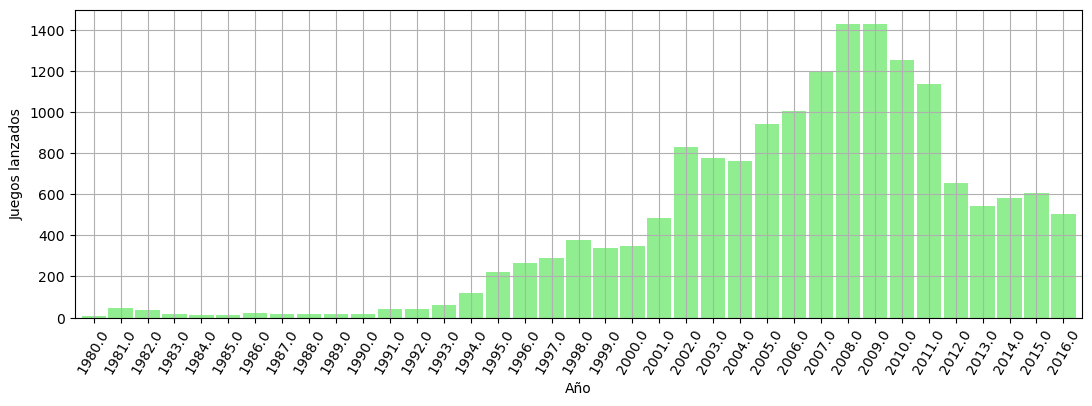

In [11]:
#Cantidad de juegos lanzados por año
yearly_launches = games.groupby('year_of_release').agg({'na_sales': 'sum',
                                                        'eu_sales': 'sum',
                                                        'jp_sales': 'sum',
                                                        'other_sales': 'sum',
                                                        'name': 'count',
                                                        'total_sales': 'sum'
                                                        })

#Generamos una grafica de barras
yearly_launches.name.plot(kind='bar',
                         color='lightgreen',
                         width=0.9,
                         figsize=(13,4)
                         )

plt.ylabel('Juegos lanzados')
plt.xlabel('Año')
plt.grid(True)
plt.xticks(rotation=60) 
plt.show()

- De 2002 a 2010 fue cuando más juegos se lanzaron por año, superando cada año los 600 juegos.

In [12]:
#Variación de ventas por plataforma

# Agrupamos por plataforma y sumamos las ventas
sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print(sales_by_platform)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/1835393025.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)


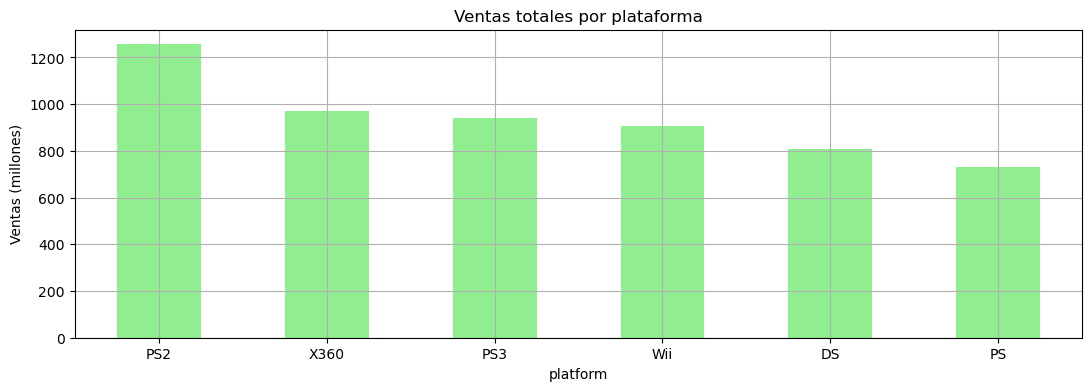

In [13]:
#Distribución basada en los datos de cada año de las plataformas con más ventas totales
# Graficamos el resultado
sales_by_platform[sales_by_platform>400].plot(kind='bar',
                                              figsize=(13, 4),
                                              color='lightgreen')
plt.title('Ventas totales por plataforma')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=0) 
plt.grid(True)

plt.show()


- Como podemos apreciar las 6 plataformas mas importantes son **PS2, X360, PS3, Wii, DS y PS**, ya que todas superaron los 700 millones.

/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/288069182.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_sales_by_year = games.groupby(['platform', 'year_of_release'])['total_sales'].sum()
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/288069182.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  more_tan_15_millions = games.groupby('platform')['total_sales'].max().sort_values(ascending=False) >15


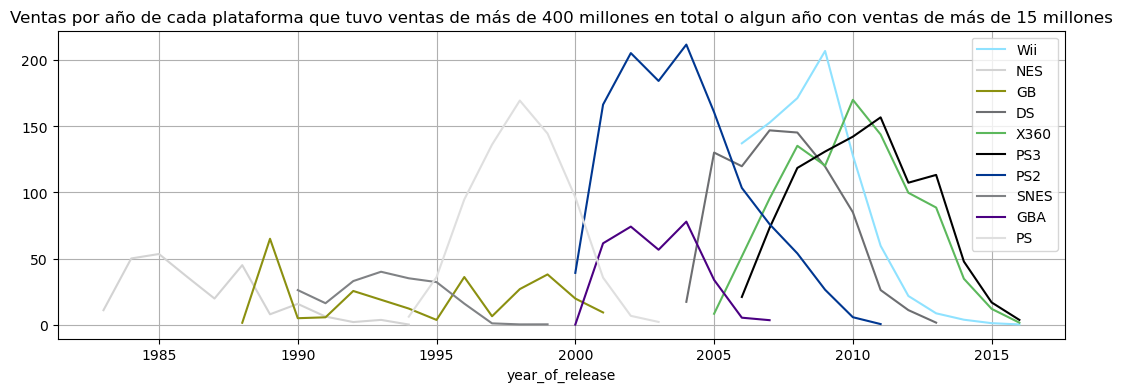

In [14]:
#Analisis de las plataformas que fueron populares, pero ya no tienen ventas
# Agrupamos por año y sumamos las ventas
platform_sales_by_year = games.groupby(['platform', 'year_of_release'])['total_sales'].sum()

fig, ax = plt.subplots(figsize=(13,4))

# Filtramos las plataformas con ventas > 400 o algun año con más de 15 millones
more_tan_15_millions = games.groupby('platform')['total_sales'].max().sort_values(ascending=False) >15
platforms = sales_by_platform[sales_by_platform > 400].index
platforms = (more_tan_15_millions[more_tan_15_millions].index[:].append(platforms)).unique()

# Mapeo exacto para mantener consistencia en tus gráficas
platform_colors = {
    'Wii':  '#8fe2ff', # Celeste/Blanco interfaz
    'NES':  '#d3d3d3', # Gris ceniza original
    'GB':   '#8b9010', # Verde oliva de la pantalla original
    'DS':   '#6d6e71', # Gris metálico
    'X360': '#5cb85c', # Verde Xbox
    'PS3':  '#000000', # Negro Piano
    'PS2':  '#003791', # Azul PlayStation
    'SNES': '#808285', # Gris oscuro de los botones
    'GBA':  '#4b0082', # Morado índigo (modelo icónico)
    'PS':   '#dfdfdf'  # Gris claro (Classic)
}

# Para usarlo en tu bucle actual:
#platforms = ['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA', 'PS']
colors = [platform_colors[p] for p in platforms]

# Usamos zip para emparejar cada plataforma con un color
for platform, color in zip(platforms, colors):
    if platform != 'DS':
        platform_sales_by_year.loc[platform][platform_sales_by_year.loc[platform] != 0].plot(color=color)
    else: #Se detecto un error en las ventas de DS en el 1985, ya que marca 0.02 millones, pero en realidad salio hasta 2004, para esto eliminamos los valores anteriores a su lanzamiento
        platform_sales_by_year.loc[platform][platform_sales_by_year.loc[platform] != 0].iloc[1:].plot(color=color)

plt.title('Ventas por año de cada plataforma que tuvo ventas de más de 400 millones en total o algun año con ventas de más de 15 millones')
plt.legend(platforms)
plt.grid(True)
plt.show()

- Aqui podemos observar 10 plataformas populares que actualmente ya casi no tienen ventas, Todas parecen tener un comportamiento similar en sus ventas, a continuación analizaremos el tiempo que toman en surgir y desaparecer.

In [15]:
#Analisis del tiempo que toman en surgir y desaparecer las plataformas
top_10 = platform_sales_by_year[platform_sales_by_year != 0]

data = []
for platform in platforms:

    if platform != 'DS':
        years = top_10.loc[platform].index
    else:
        years = top_10.loc[platform].iloc[1:].index
    first, last, top = years.min(), years.max(), top_10.loc[platform].max()
    top = top_10[top_10 == top].reset_index()['year_of_release'][0] - first
    end = last - first + 1 #Se suma un año, ya que last es el ultimo año que se registraron ventas y nosotros buscamos el año siguiente a ese, que fue en el que ya no se vendio nada
    data.append({'platform': platform, 'mejor_año': top, 'dejo_de_vender': end})

df = pd.DataFrame(data).set_index('platform')

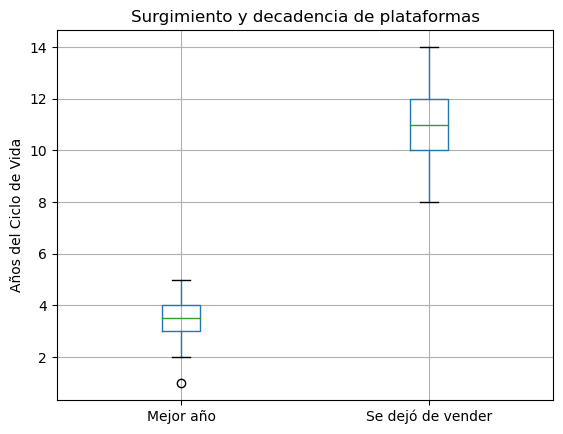


Promedio
mejor_año          3.4
dejo_de_vender    11.0
dtype: float64 

Desviación estandar
mejor_año         1.26
dejo_de_vender    1.63
dtype: float64


In [16]:
#Grafica de caja para el mejor año por platafroma y los años que pasan hasta que deja de vender
df.boxplot()
plt.title('Surgimiento y decadencia de plataformas')
plt.xticks([1, 2], ['Mejor año', 'Se dejó de vender'])
plt.ylabel('Años del Ciclo de Vida')
plt.show()

#Mostramos estadistica descriptiva
print('\nPromedio')
print(df.mean(), '\n')

print('Desviación estandar')
print(round(np.sqrt(df.var()), 2))

- Gracias al analisis estadistico podemos concluir que los juegos de las plataformas exitosas tuvieron su mejor año en promedio depues de 3.4 años del lanzamiento de la misma, con una desviación estandar de 1.26 y en promedio dejaron de vender despúes de 11 años de su lanzamiento, con una desviación estandar de 1.63.
- Además gracias a la grafica de caja podemos concluir que el mejor año de una plataforma exitosa va del año 2 al año 5, aproximadamente, mientras va de 8 a 14 años el tiempo que pasa para que esa plataforma deje de vender juegos.

### Determinación del periodo que se tomara de datos para construir modelo del 2017 (de acuerdo a respuestas anteriros)

- Sería conveniente tomar los datos que abarquen lo suficiente para ver una plataforma surgir y desaparecer, para lo cual tomaremos el máximo de lo que le toma a una plataforma para desaparecer, la cual es de 14 años.

<Axes: xlabel='year_of_release'>

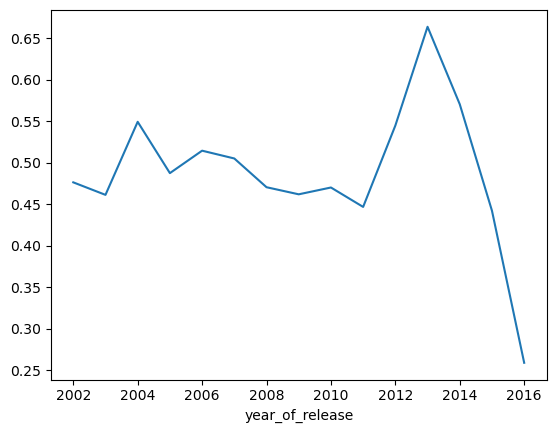

In [17]:
#Ventas promedio de los ultimos 14 años
games.groupby('year_of_release')['total_sales'].mean().loc[2016-14:].plot()

In [18]:
#DF de ventas de juegos lanzados del 2002 en adelante
df_2002_en_adelante = games[(games['year_of_release'] >=2002) & (games['total_sales'] > 0)]

#### Plataformas lideres

In [19]:
#Plataformas lideres en ventas, cuales crecen y cuales se reducen
grouped_2_to_16 = df_2002_en_adelante.groupby(['platform', 'year_of_release'])[['total_sales']].sum()

# 'unstack' mueve el nivel del índice 'platform' a las columnas
df_final = grouped_2_to_16['total_sales'].unstack(level='platform').fillna(0)

# Solo los que más vendieron los ultimos 3 años 
df_final = df_final[df_final.index >= 2014]
df_final = df_final.loc[:, (df_final != 0).any(axis=0)].sum()
leaders, loosers = df_final.sort_values().index[-3:], df_final.sort_values().index[:3]

#Imprimir plataformas lider y su promedio de venta los ultimos 3 años
print('\n', 'Plataformas lider')
print(df_final.loc[leaders])

#Imprimir plataformas que se reducen y su promedio de venta los ultimos 3 años
print('\n', 'Plataformas')
print(df_final.loc[loosers])


 Plataformas lider
platform
3DS      86.68
XOne    140.36
PS4     288.15
dtype: float64

 Plataformas
platform
PSP     0.36
Wii     5.07
PSV    22.40
dtype: float64


/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/265220444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_2_to_16 = df_2002_en_adelante.groupby(['platform', 'year_of_release'])[['total_sales']].sum()


In [20]:
#Exztraemos los años que tienen en el mercado las plataformas lideres
for leader in leaders:
    print('\n', leader, grouped_2_to_16[grouped_2_to_16 > 0].loc[leader].count()[0])


 3DS 6

 XOne 4

 PS4 4


/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/930189077.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('\n', leader, grouped_2_to_16[grouped_2_to_16 > 0].loc[leader].count()[0])
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/930189077.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('\n', leader, grouped_2_to_16[grouped_2_to_16 > 0].loc[leader].count()[0])
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/930189077.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be tr

Las plataformas potencialmente rentables serian **3DS**, **XOne**, **PS4** de acuerdo a las ventas de lo ultimos 3 años. Pero 3DS ya tiene 6 años en el mercado, signofica que ya pasaron sus mejores años, por ello nos quedaremos con **XOne** y **PS4** como plataformas con gran potencial.

In [21]:
# Plataformas con ventas de 2002 en adelante
sales = df_2002_en_adelante.groupby('platform')['total_sales'].sum()
sales = sales[sales != 0]

# Eliminar plataformas sin ventas
df = grouped_2_to_16.reset_index()
df['platform'] = df['platform'].astype(str)
df = df.query('platform in @sales.index')

/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/478365150.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales = df_2002_en_adelante.groupby('platform')['total_sales'].sum()


#### Diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.

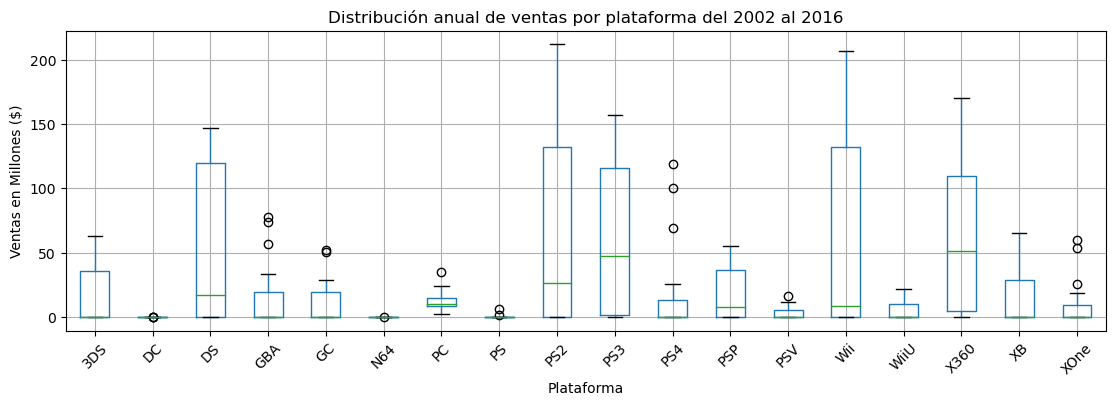

In [22]:
df.boxplot(column='total_sales', by='platform', figsize=(13,4), rot=45)

plt.title('Distribución anual de ventas por plataforma del 2002 al 2016')
plt.ylabel('Ventas en Millones ($)')
plt.xlabel('Plataforma')
plt.suptitle('')
plt.show()

In [23]:
mean_ = df[df['total_sales'] > 0].groupby('platform')[['total_sales']].mean()
std = np.sqrt(df[df['total_sales'] > 0].groupby('platform')[['total_sales']].var())

print('Media\n', mean_)

print('\nDesviación\n', std)

Media
           total_sales
platform             
3DS         42.968333
DC           0.116667
DS          80.276000
GBA         41.880000
GC          28.398333
N64          0.080000
PC          13.039333
PS           4.370000
PS2        102.796000
PS3         84.667273
PS4         78.535000
PSP         24.127500
PSV          8.968333
Wii         81.016364
WiiU        16.438000
X360        80.103333
XB          32.617143
XOne        39.830000

Desviación
           total_sales
platform             
3DS         18.278261
DC           0.150444
DS          59.796231
GBA         32.995437
GC          20.626068
N64               NaN
PC           8.653179
PS           3.252691
PS2         82.502804
PS3         54.637565
PS4         40.567917
PSP         20.190759
PSV          4.729695
Wii         79.136330
WiiU         7.068244
X360        57.484408
XB          27.919452
XOne        20.313977


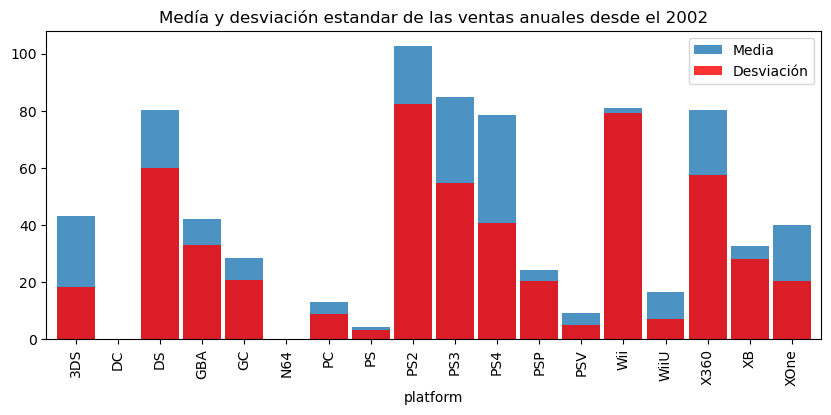

In [24]:
fig, ax = plt.subplots(figsize = [10, 4])
mean_.plot(ax=ax,
          kind='bar',
          width=0.9,
          alpha=0.8)

std.plot(ax=ax,
         kind='bar',
         width=0.9,
         color='red',
        alpha=0.8)

plt.title('Medía y desviación estandar de las ventas anuales desde el 2002')
plt.legend(['Media', 'Desviación'])
plt.show()

- La diferencia en las ventas es muy notoría en los diagramas de caja, podemos ver como resaltan **DS, PS2, PS3, Wii, X360** con gran diferencia.
- La media de las ventas de **DS, PS2, PS3, PS4, Wii, X360** son notoriamente más altas que el resto de las plataformas pero tienen una desviación bastante alta, casi tanta como el resto de las plataformas. 

#### Impacto de las reseñas profesionales y de los usuarios en PS4 y XOne

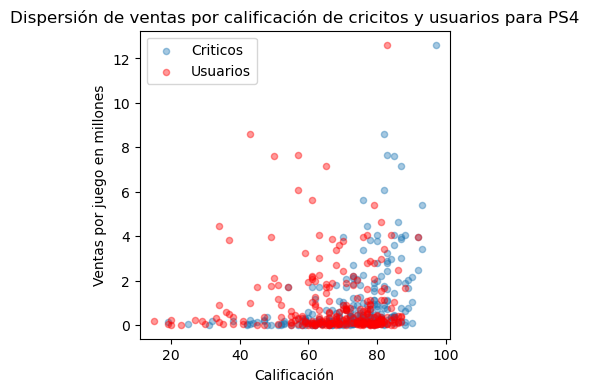

Correlación de ventas totales con:
Criticos 0.41
Usuarios -0.03, 



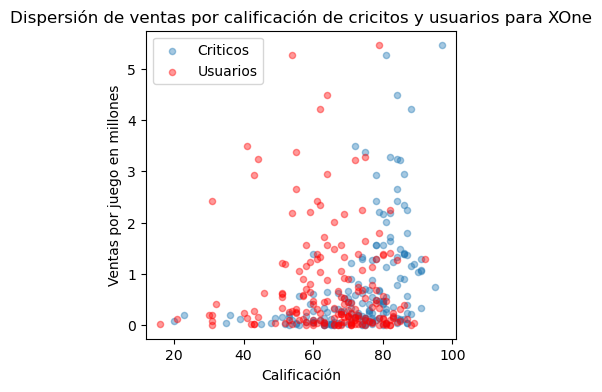

Correlación de ventas totales con:
Criticos 0.42
Usuarios -0.07, 



In [25]:
#Impacto de reseñas profesionales y de usuarios en las ventas de una plataforma popular seleccionada 
df_ = df_2002_en_adelante.copy()
df_.loc[:, 'user_score'] = df_['user_score'] * 10

def score_scatter_plot(df, platform):
    ### Grafico de dispersion de impacto de las calificaciones en las ventas 
    fig, ax = plt.subplots(figsize=[4,4])

    df = df[df.loc[:,'platform'] == platform]
    df.plot(kind='scatter',
              x='critic_score',
              y='total_sales',
              alpha=0.4,
              ax=ax)
    
    df.plot(kind='scatter',
              x='user_score',
              y='total_sales',
              alpha=0.4,
              ax=ax,
              color='red')
    plt.legend(['Criticos', 'Usuarios'])
    plt.title(f'Dispersión de ventas por calificación de cricitos y usuarios para {platform}')
    plt.xlabel('Calificación')
    plt.ylabel('Ventas por juego en millones')
    plt.show()

    print('Correlación de ventas totales con:')
    print(f"Criticos {round(df['critic_score'].corr(df['total_sales']), 2)}")
    print(f"Usuarios {round(df['user_score'].corr(df['total_sales']), 2)}, \n")

score_scatter_plot(df_, 'PS4')

score_scatter_plot(df_, 'XOne')

- La correlación no es suficientemente significativa en ninguno de los casos en ambas plataformas, ya que no alcanzan el 0.5, esto se confirma con las graficas de dispersión.

#### Comparación de las ventas de los mismos juegos por pltaforma

In [26]:
# Juegos populares
game_platform = df_[df_ !=0].groupby('name')['total_sales'].sum().sort_values()
print(game_platform[game_platform > 25],'\n')

print(game_platform[game_platform > 25].index)

name
Call of Duty: Black Ops 3         25.67
Call of Duty: Ghosts              27.39
New Super Mario Bros. Wii         28.32
Wii Play                          28.91
Call of Duty: Black Ops           29.20
Call of Duty: Black Ops II        29.40
New Super Mario Bros.             29.80
Call of Duty: Modern Warfare 3    30.60
Wii Sports Resort                 32.77
Mario Kart Wii                    35.52
Grand Theft Auto V                56.58
Wii Sports                        82.54
Name: total_sales, dtype: float64 

Index(['Call of Duty: Black Ops 3', 'Call of Duty: Ghosts',
       'New Super Mario Bros. Wii', 'Wii Play', 'Call of Duty: Black Ops',
       'Call of Duty: Black Ops II', 'New Super Mario Bros.',
       'Call of Duty: Modern Warfare 3', 'Wii Sports Resort', 'Mario Kart Wii',
       'Grand Theft Auto V', 'Wii Sports'],
      dtype='object', name='name')


- Seleccionamos los juegos más populares

In [27]:
# Contamos en cuántas plataformas aparece cada nombre de juego
multiplatform_games = games.groupby('name')['platform'].nunique()

# Nos quedamos solo con los nombres que aparecen en 2 o más
multi_names = multiplatform_games[multiplatform_games > 1].index

# Filtramos el DataFrame original para tener solo esos juegos
df_multi = games[games['name'].isin(multi_names)]

- Ahora con los juegos multi-plataforma más populares hacemos una tabla de pivote

In [28]:
# Creamos una tabla pivote
comparison_table = df_multi.pivot_table(index='name', 
                                        columns='platform', 
                                        values='total_sales', 
                                        aggfunc='sum')

# Usamos los más populares multi-plataforma
names = multi_names.intersection(game_platform[game_platform > 25].index)
#print(comparison_table.loc[names].T.loc[mean_.index])

/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/2501994703.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  comparison_table = df_multi.pivot_table(index='name',


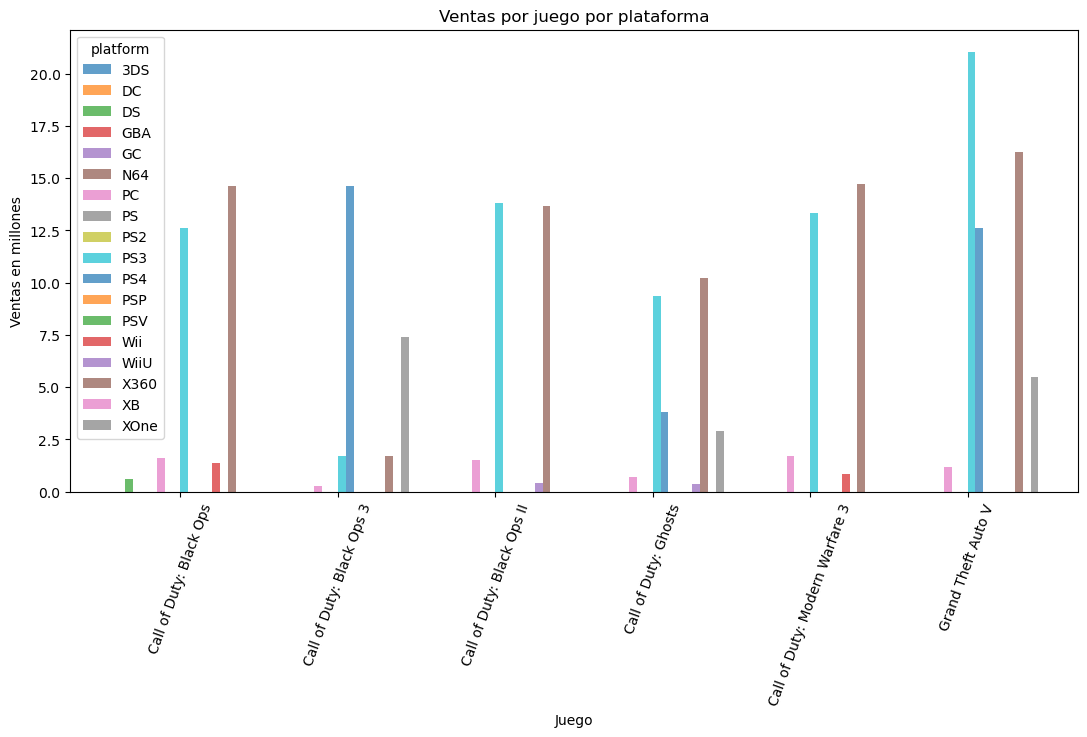

In [29]:
comparison_table.loc[names].loc[:,mean_.index].plot(kind='bar',
                                                   figsize=(13,6),
                                                   rot=70,
                                                   width=0.9,
                                                   alpha=0.7)
plt.title('Ventas por juego por plataforma')
plt.xlabel('Juego')
plt.ylabel('Ventas en millones')
plt.show()

- Como podemos notar, tanto PS3 como X360, tienen un notorio dominio en 5 de los 6 juegos seleccionados, mientras en uno de los juegos estan depues de otros dos, los cuales son las versiones más recientes de estas dos plataformas.

              total_sales
genre                    
Shooter          0.821118
Platform         0.672343
Sports           0.576469
Role-Playing     0.552967
Racing           0.527424
Action           0.482749
Fighting         0.461282
Misc             0.442560
Simulation       0.431034
Puzzle           0.279712
Strategy         0.193002
Adventure        0.148349 



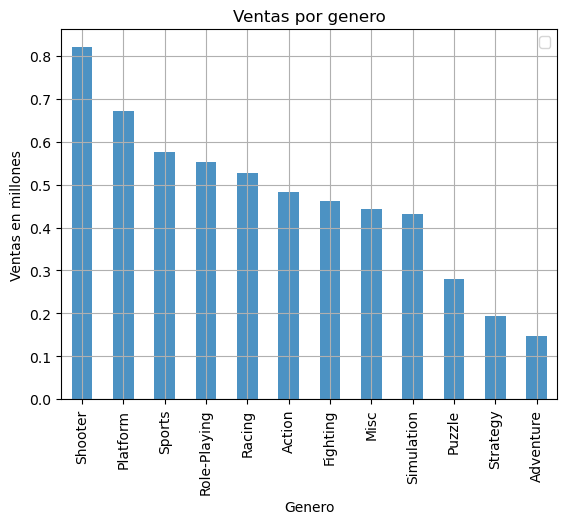

In [30]:
#Distribución general de juegos por género (Analisis de generos más y menos rentables)
by_genre = df_.groupby('genre')[['total_sales']].mean().sort_values('total_sales',ascending=False)
print(by_genre, '\n')

by_genre.plot(kind='bar',
             title='Ventas por genero',
             alpha=0.8,
             xlabel='Genero',
             ylabel='Ventas en millones',
             grid=True)

plt.legend('')
plt.show()

- Notoriamente los 2 generos más rentables son **Shooter y Platform** mientras los generos menos rentables serian **Strategy y Adventure**, con menos de un tercio de las ventas de los anteriormente mencionados *Shooter y Platform*.

### Perfil de usuario por region

Para cada región (NA, UE, JP) se determina:

- Las cinco plataformas principales. Variaciones en sus cuotas de mercado de una región a otra.
- Los cinco géneros principales.
- Impacto de las clasificaciones de ESRB en las ventas en regiones individuales.

In [31]:
# Funciones para perfil 
regiones = ['na_sales', 'eu_sales', 'jp_sales']

def top_5_region(df, regional, search):
    df = df.groupby(search)[[regional]].sum().sort_values(regional, ascending=False).head()
    df['porcentaje'] = round(df / df.sum(), 2)
    return df


In [32]:
# 5 principales plataformas por region
for reg in regiones:
    print(top_5_region(df_, reg, 'platform'), '\n')

          na_sales  porcentaje
platform                      
X360        595.74        0.26
Wii         486.87        0.21
PS2         477.35        0.20
PS3         390.13        0.17
DS          380.31        0.16 

          eu_sales  porcentaje
platform                      
PS3         327.21        0.25
PS2         269.62        0.21
X360        268.32        0.20
Wii         258.32        0.20
DS          188.41        0.14 

          jp_sales  porcentaje
platform                      
DS          175.00        0.32
PS2         110.88        0.20
3DS         100.62        0.19
PS3          79.41        0.15
PSP          75.88        0.14 



/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(search)[[regional]].sum().sort_values(regional, ascending=False).head()
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(search)[[regional]].sum().sort_values(regional, ascending=False).head()
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

- Es notorio que cada region tiene su plataforma favorita, X360 para NA, PS3 en EU y DS en JP.

In [33]:
# 5 principales generos
for reg in regiones:
    print(top_5_region(df_, reg, 'genre'), '\n')

              na_sales  porcentaje
genre                             
Action          704.67        0.30
Sports          537.84        0.23
Shooter         476.12        0.20
Misc            348.17        0.15
Role-Playing    267.64        0.11 

         eu_sales  porcentaje
genre                        
Action     436.49        0.31
Sports     315.67        0.23
Shooter    284.35        0.20
Misc       187.55        0.13
Racing     167.63        0.12 

              jp_sales  porcentaje
genre                             
Role-Playing    216.36        0.40
Action          122.50        0.23
Misc             81.40        0.15
Sports           65.62        0.12
Platform         49.17        0.09 



- En ninguna de las regiones observadas coincide el principal genero con el total global y aun así cada genero principal por region pose más del 30% de las ventas por region.

In [34]:
# Impacto de las clasificaciones ESRB en las ventas regionales
for reg in regiones:
    print(top_5_region(df_, reg, 'rating'), '\n')

        na_sales  porcentaje
rating                      
E        1139.37        0.35
M         698.99        0.21
T         650.02        0.20
uknown    424.46        0.13
E10+      345.50        0.11 

        eu_sales  porcentaje
rating                      
E         630.17        0.33
M         456.15        0.24
T         358.49        0.19
uknown    309.06        0.16
E10+      183.33        0.09 

        jp_sales  porcentaje
rating                      
uknown    349.88        0.48
E         175.38        0.24
T         114.29        0.16
M          53.44        0.07
E10+       40.20        0.05 



/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(search)[[regional]].sum().sort_values(regional, ascending=False).head()
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(search)[[regional]].sum().sort_values(regional, ascending=False).head()
/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/791646832.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

In [35]:
print('Distribución global de clasificaciones\n')
global_esrb = df_.groupby('rating')[['total_sales']].sum().sort_values('total_sales', ascending=False).head()
print(global_esrb / global_esrb.sum())

Distribución global de clasificaciones

        total_sales
rating             
E          0.326268
M          0.208194
T          0.190661
uknown     0.178090
E10+       0.096787


/var/folders/qx/s9msr97d0jz1x633zbtvmqx40000gn/T/ipykernel_58410/4219633794.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  global_esrb = df_.groupby('rating')[['total_sales']].sum().sort_values('total_sales', ascending=False).head()


- La clasificación **E** pose **35%, 33% y 24%** de las ventas regionales, acercandose bastante al **32.6% global**, además en todas las regiones coincide el Top 5, en diferente orden.

### Pruebas de hipótesis

In [36]:
# Funcion para prueba de hipotesis de igualdad de 2 data set
def user_score_hipotesis(df, searches, in_, alpha=0.05):
    # Generar los 2 data set separados
    xone_ratings = df[df[in_] == searches[0]]['user_score'].dropna()
    pc_ratings = df[df[in_] == searches[1]]['user_score'].dropna()
    
    # Comparamos las varianzas de las calificaciones
    levene_res = st.levene(xone_ratings, pc_ratings)
    print('p-value de Levene:', levene_res.pvalue)
    
    if levene_res.pvalue < 0.05: equal_var = False
    else: equal_var = True
    
    #Prueba de hipótesis
    results = st.ttest_ind(xone_ratings, pc_ratings, equal_var=equal_var)
    
    print('p-value:', results.pvalue)
    
    if results.pvalue < alpha:
        print("\nRechazamos la hipótesis nula: Las calificaciones son diferentes.")
    else:
        print("\nNo podemos rechazar la hipótesis nula: Las calificaciones son similares.")


#### Hipotesis 1
- H0: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [37]:
user_score_hipotesis(df_, ['XOne', 'PC'], 'platform')

NameError: name 'st' is not defined

#### Formulación de hipótesis nula y alternativa.
- La hipotesis nula siempre se hace sobre una igualdad, al estar interesados en saber si **XOne y PC tienen calificaciones iguales**, determinamos que H0 sería determinar si existe una igualdad y por lo tanto h1 sería que son diferentes. ***Hipótesis nula rechazada***.

#### Criterios utilizados para probar las hipótesis.
- Tomamos **Alpha de 0.05** para darle un poco de flexibilidad ya que la prueba de levene nos dio un p_value >0.2 y además, hay bastantes juegos que no se repiten en ambas plataformas.
- Usamos la prueba de **levene** para determianar si tienen una **varianza igual** y determiar correctamente el parametro en la prueba de hipótesis.
- Se ejecuta la prueba **ttest_ind** porque es justo la prueba ideal cuando se busca comparar dos data set.

#### Hipótesis 2
- H0: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

In [ ]:
user_score_hipotesis(df_, ['Action', 'Sports'], 'genre', 0.01)

In [ ]:
#Calificación promedio del usuario para Acción y Deportes
print(df_.groupby('genre')[['user_score']].mean().loc[['Action', 'Sports']])

#### Formulación de hipótesis nula y alternativa.
- Al estar interesados en saber si los genero **Action y Sports tienen calificaciones iguales**, determinamos H0 sería: **las calificaciones de los usuarios Acción y Deportes son iguales** y por lo tanto h1: **las calificaciones de los usuarios Acción y Deportes son iguales**.  ***Hipótesis nula no rechazada***.

#### Criterios utilizados para probar las hipótesis.
- Tomamos **Alpha de 0.01** ya que necesitamos una prueba más estricta para comparar calificaciones sobre los generos de los juegos. Lo cual se refuerza al notar que sus promedios de **calificación son de 70.39 y 69.04** (muy cercanos, con una *diferencia de apenas el 1.92%*). Esto nos ayuda a evitar un **Falso Positivo**.
- Usamos la prueba de **levene** para determianar si tienen una **varianza igual** y determiar correctamente el parametro *equal_var* en la prueba de hipótesis.
- Se ejecuta la prueba **ttest_ind** siendo la prueba ideal cuando se busca comparar dos data set.

# Conclusión General: Análisis del Mercado de Videojuegos (2002-2016)

### 1. Preparación y Calidad de los Datos
El proceso de limpieza aseguró la integridad del análisis mediante la estandarización a `snake_case` y la corrección de tipos de datos. Se gestionaron los valores ausentes en **'name'** y **'genre'** como `'unknown'` para evitar sesgos en la agrupación. Un paso crítico fue la transformación de `'tbd'` en `user_score` a valores nulos, permitiendo el cálculo numérico tras normalizar la escala a un rango de 0-100 para equipararla con las críticas de expertos.

### 2. Dinámica del Ciclo de Vida de las Plataformas
El análisis histórico revela que el mercado alcanzó su pico de lanzamientos entre 2002 y 2010. Se identificaron las 6 plataformas líderes (**PS2, X360, PS3, Wii, DS y PS**) como los referentes históricos con ventas superiores a los 700 millones de USD.

* **Patrón de éxito:** Las plataformas tardan, en promedio, **3.4 años** en alcanzar su madurez comercial (mejor año) y tienen una vida útil total de aproximadamente **11 años**.
* **Ventana de oportunidad:** Los datos muestran que el periodo de máximo rendimiento ocurre entre el **año 2 y el año 5** tras el lanzamiento.

### 3. Estrategia y Pronóstico para 2017
Para el modelo predictivo de 2017, se determinó que el periodo de relevancia debe cubrir el ciclo de vida observado (hasta 14 años para capturar la decadencia total).

* **Plataformas Objetivo:** Aunque la **3DS** muestra ventas sólidas, su antigüedad de 6 años sugiere que ha entrado en su fase de declive. Por lo tanto, **PS4 y Xbox One** se perfilan como las plataformas con mayor potencial de rentabilidad para 2017, al encontrarse aún en una etapa competitiva de su ciclo de vida.
* **Factores de Éxito:** Los géneros **Shooter y Platform** dominan la rentabilidad global, mientras que la correlación entre las ventas y las calificaciones (críticos/usuarios) es débil (menor a 0.5), lo que indica que el éxito comercial depende más del marketing, la marca y la exclusividad que de la puntuación promedio.

### 4. Perfilamiento Regional
Existe una fragmentación clara en las preferencias: **X360** domina en Norteamérica, **PS3** en Europa y **DS** en Japón. A pesar de estas diferencias de hardware, la clasificación **E (Everyone)** mantiene una consistencia global, representando cerca del 32.6% de las ventas en todas las regiones.

### 5. Verificación de Hipótesis Estadísticas
* **Xbox One vs. PC:** Se rechazó la hipótesis nula ($p < 0.05$), confirmando que las calificaciones promedio de los usuarios **son diferentes** entre estas plataformas.
* **Acción vs. Deportes:** Utilizando un nivel de significancia más estricto ($\alpha = 0.01$) debido a la cercanía de los promedios (solo 1.92% de diferencia), **no se pudo rechazar la hipótesis nula**. Se concluye que las calificaciones para los géneros de Acción y Deportes son estadísticamente similares.